In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids

from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator

In [2]:
data = pd.read_csv('dataset.csv')
data = data.drop('prov', axis=1)
data

,mag,depth,rad,lat,lon,prov_enco
0,3.6,10,74,-3.92,133.71,1
1,2.6,164,3,1.49,99.64,2
2,4.5,182,165,-4.60,129.69,3
3,3.2,10,116,-8.50,107.82,4
4,5.0,11,129,1.96,126.60,5
...,...,...,...,...,...,...
1934,3.2,10,29,4.54,96.59,9
1935,2.9,10,107,1.78,122.85,15
1936,4.4,386,187,-6.47,127.97,14
1937,3.1,24,69,1.39,126.93,5


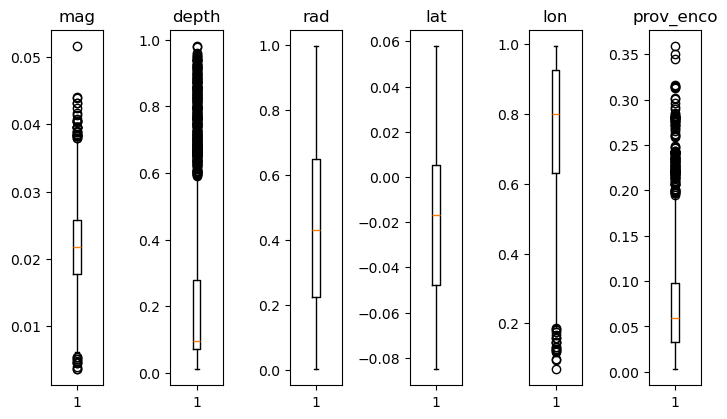

In [3]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

plt.figure(figsize=(12, 8))
for i, column in enumerate (dataScaled.columns, 1):
    plt.subplot(2, 10, i)
    plt.boxplot(dataScaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

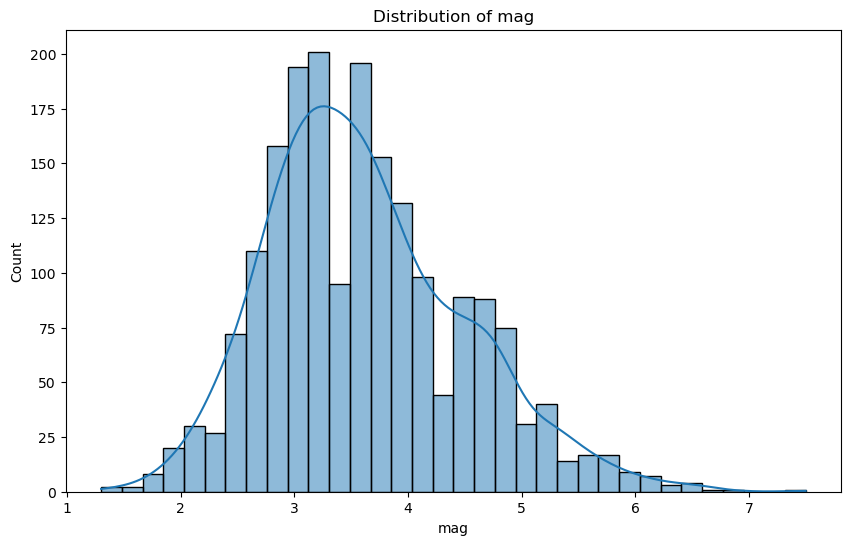

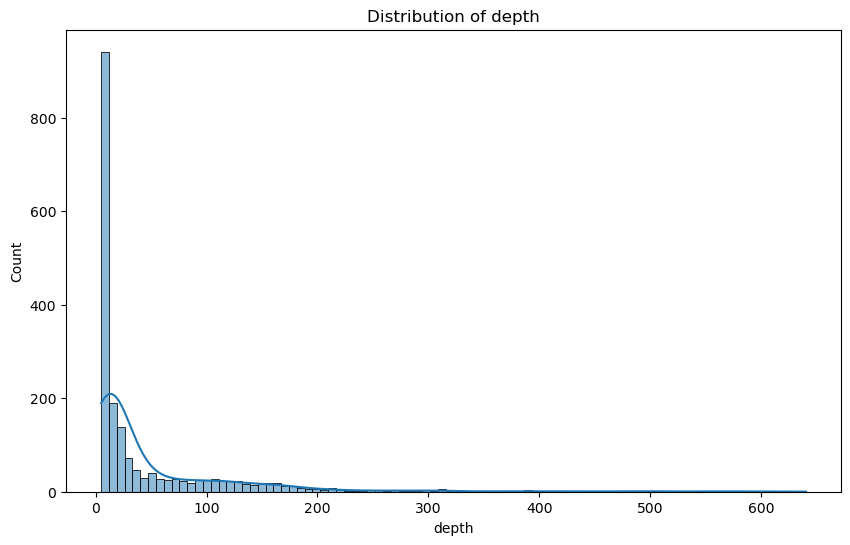

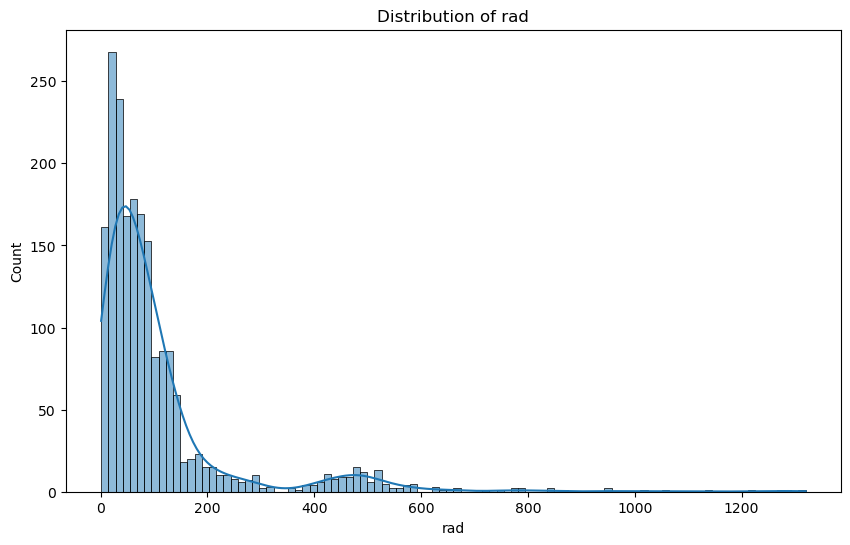

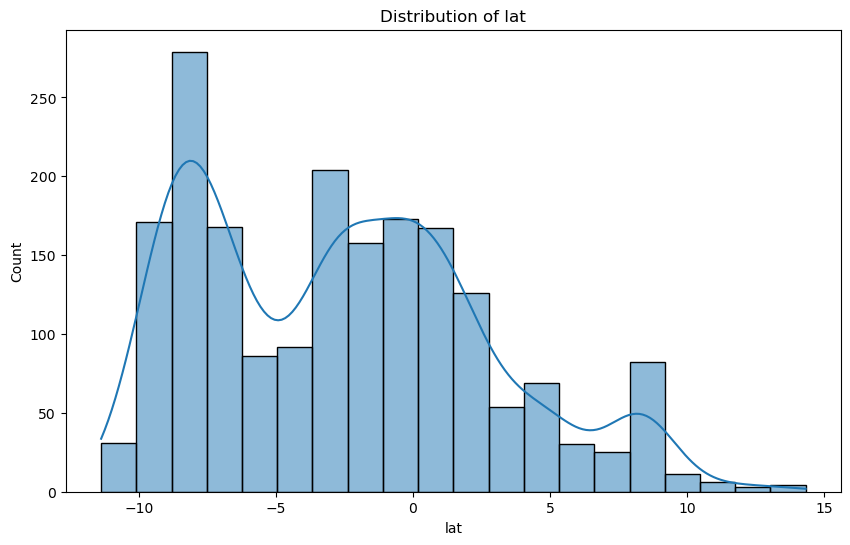

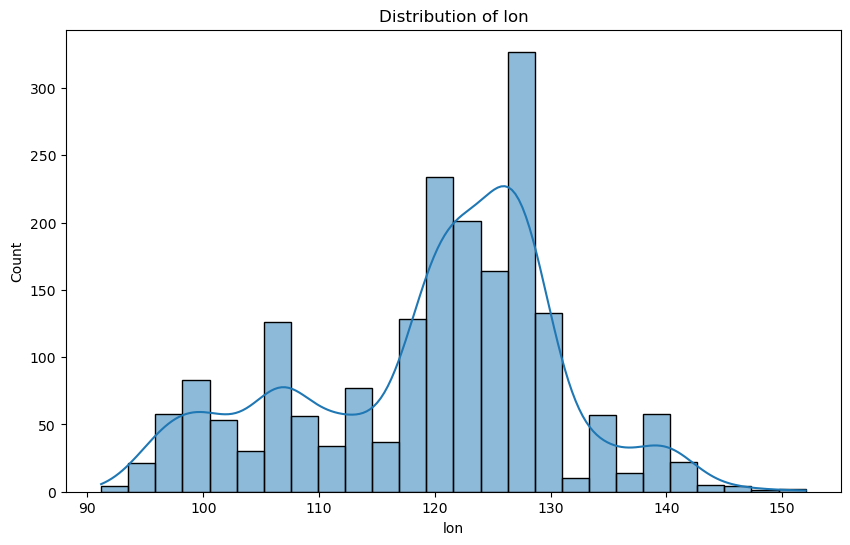

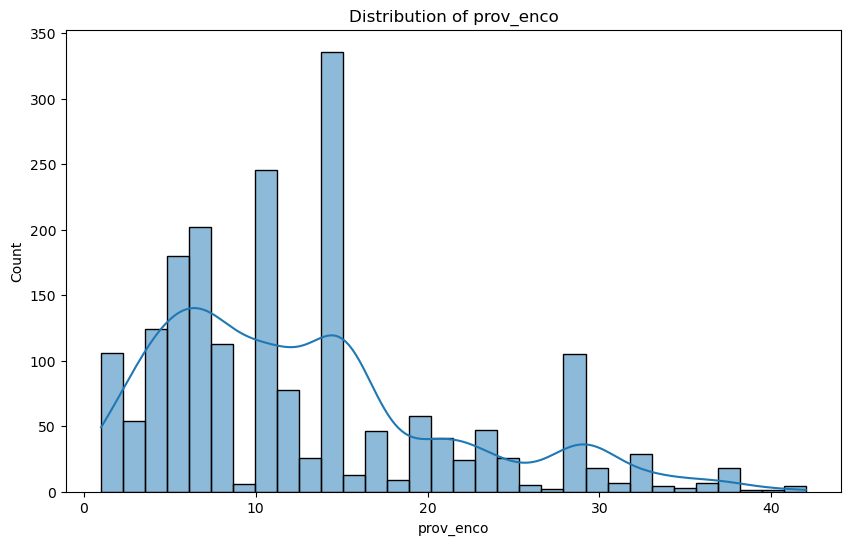

In [4]:
for column in dataScaled.columns[:6]:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

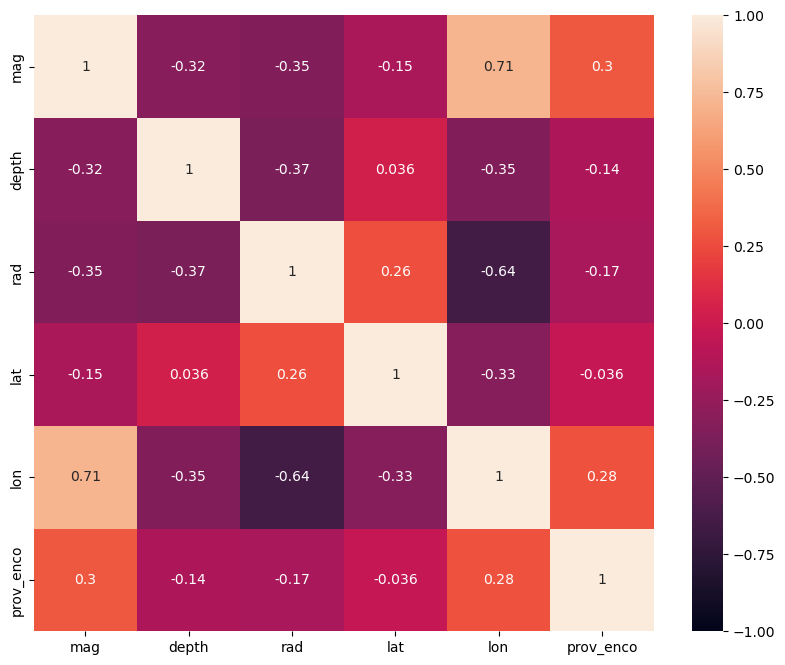

In [5]:
correlation = dataScaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)
plt.show()

C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:252: UserWarning: n_clusters should be larger than 2 if max_iter != 0 setting max_iter to 0.
  warnings.warn(


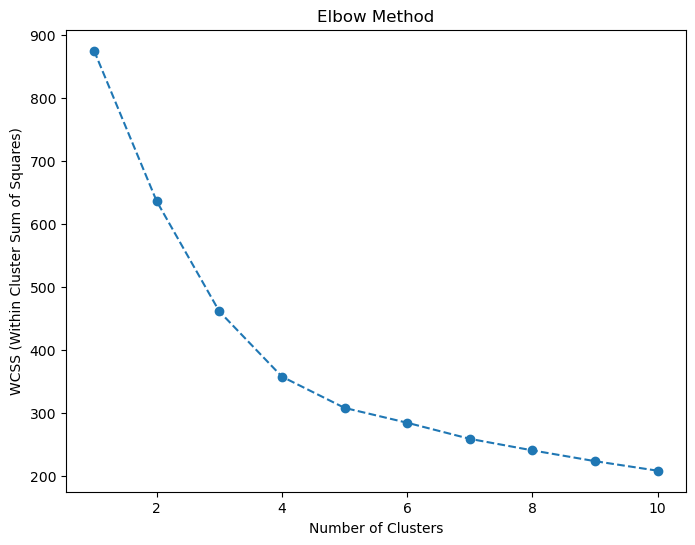

In [59]:
reduced_data = PCA(n_components=2).fit_transform(dataScaled)
wcss = []

for i in range(1, 11):
    kMedoids = KMedoids(metric="manhattan", n_clusters=i, method='pam', random_state=42)
    kMedoids.fit(reduced_data)
    wcss.append(kMedoids.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [60]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

4

In [66]:
kMedoids = KMedoids(n_clusters=cluster_knee.elbow, method='pam', random_state=42)
predict = kMedoids.fit(reduced_data)
predict

KMedoids(method='pam', n_clusters=4, random_state=42)

In [73]:
data['cluster'] = predict.labels_
data['cluster'].value_counts()

cluster
2    716
3    644
1    350
0    229
Name: count, dtype: int64

In [69]:
avg = silhouette_score(reduced_data, predict.labels_)
avg

0.5238122637848475

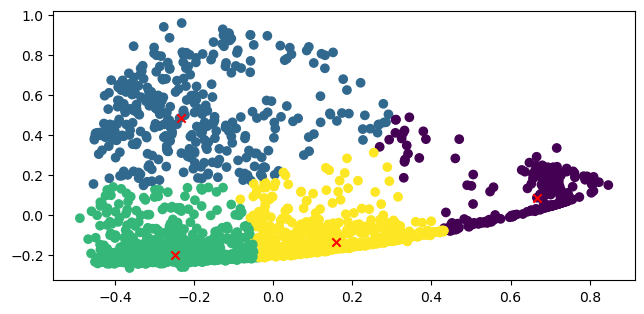

In [71]:
plt.figure(figsize=(7.5, 3.5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=predict.labels_, cmap='viridis')
plt.scatter(predict.cluster_centers_[:, 0], predict.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

In [74]:
data

,mag,depth,rad,lat,lon,prov_enco,cluster
0,3.6,10,74,-3.92,133.71,1,3
1,2.6,164,3,1.49,99.64,2,1
2,4.5,182,165,-4.60,129.69,3,1
3,3.2,10,116,-8.50,107.82,4,3
4,5.0,11,129,1.96,126.60,5,3
...,...,...,...,...,...,...,...
1934,3.2,10,29,4.54,96.59,9,2
1935,2.9,10,107,1.78,122.85,15,3
1936,4.4,386,187,-6.47,127.97,14,1
1937,3.1,24,69,1.39,126.93,5,3
